In [1]:
# 🔧 NOTEBOOK 3 : FEATURE ENGINEERING

## 🎯 Objectif : Transformer et enrichir les données pour préparer le machine learning en créant de nouvelles features pertinentes et en encodant les variables catégorielles.

## 📦 1. IMPORTS ET CONFIGURATION

# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports réussis !")

✅ Imports réussis !


In [2]:
#2.  Chargement des données nettoyées
df = pd.read_csv('../data/processed/data_clean.csv')

print("="*80)
print("📋 DONNÉES INITIALES")
print("="*80)
print(f"\n✅ Nombre d'observations : {len(df)}")
print(f"✅ Nombre de variables : {df.shape[1]}")
print(f"\n📌 Aperçu des données :")
print(df.head(10))

print(f"\n📌 Types de données :")
print(df.dtypes)

print(f"\n📌 Informations générales :")
print(df.info())

📋 DONNÉES INITIALES

✅ Nombre d'observations : 3803
✅ Nombre de variables : 20

📌 Aperçu des données :
      id_field crop_season      village      soil  area tillage_system  \
0  F2006070001      Y06_07  Antsahamamy  hillside  10.0           till   
1  F2006070002      Y06_07  Antsahamamy  hillside  15.0             ca   
2  F2006070003      Y06_07  Antsahamamy   lowland   3.1           till   
3  F2006070004      Y06_07  Antsahamamy   lowland   6.3           till   
4  F2006070005      Y06_07  Antsahamamy  hillside  41.0           till   
5  F2006070006      Y06_07  Antsahamamy   lowland   4.2           till   
6  F2006070007      Y06_07  Antsahamamy  hillside  15.0           till   
7  F2006070008      Y06_07  Antsahamamy  hillside  10.8           till   
8  F2006070009      Y06_07  Antsahamamy   lowland   8.0           till   
9  F2006070010      Y06_07  Antsahamamy  hillside   6.0           till   

  CA_year    sow_date x24d glypho  manure   urea    npk  nitrogen  rain_sow  \
0  

In [3]:
# Créer une copie pour le feature engineering
df_fe = df.copy()

print(f"\n✅ Copie créée pour le feature engineering")


✅ Copie créée pour le feature engineering


In [4]:
## 3. ENCODAGE DES VARIABLES CATÉGORIELLES (ONE-HOT ENCODING)
print("\n" + "="*80)
print("🎨 ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*80)

# CORRECTION: Identifier les variables catégorielles dans vos données
categorical_cols = df_fe.select_dtypes(include=['object']).columns.tolist()

# Exclure les colonnes de date et d'identification si nécessaire
cols_to_exclude = ['id_field', 'sow_date', 'sow_date_parsed', 'crop_season']
categorical_cols = [col for col in categorical_cols if col not in cols_to_exclude]

print(f"\n📌 Variables catégorielles à encoder : {categorical_cols}")

# Afficher les valeurs uniques pour chaque variable catégorielle
for col in categorical_cols:
    unique_values = df_fe[col].unique()
    print(f"\n   {col} : {len(unique_values)} valeurs uniques")
    print(f"      → {unique_values[:10]}{'...' if len(unique_values) > 10 else ''}")


🎨 ENCODAGE DES VARIABLES CATÉGORIELLES

📌 Variables catégorielles à encoder : ['village', 'soil', 'tillage_system', 'CA_year', 'x24d', 'glypho']

   village : 5 valeurs uniques
      → <StringArray>
['Antsahamamy', 'Ambohimiarina', 'Ambohitsilaozana', 'Ambongabe',
 'Ampitatsimo']
Length: 5, dtype: str

   soil : 2 valeurs uniques
      → <StringArray>
['hillside', 'lowland']
Length: 2, dtype: str

   tillage_system : 2 valeurs uniques
      → <StringArray>
['till', 'ca']
Length: 2, dtype: str

   CA_year : 5 valeurs uniques
      → <StringArray>
['Y0', 'Y1', 'Y3', 'Y2', 'Y4+']
Length: 5, dtype: str

   x24d : 2 valeurs uniques
      → <StringArray>
['N', 'Y']
Length: 2, dtype: str

   glypho : 2 valeurs uniques
      → <StringArray>
['N', 'Y']
Length: 2, dtype: str


In [5]:
# One-Hot Encoding pour les variables catégorielles

# 1. Variable 'tillage_system' (till vs ca)
if 'tillage_system' in df_fe.columns:
    print(f"\n🔹 Encodage de 'tillage_system' :")
    tillage_encoded = pd.get_dummies(df_fe['tillage_system'], prefix='tillage', drop_first=False)
    print(f"   Colonnes créées : {tillage_encoded.columns.tolist()}")
    df_fe = pd.concat([df_fe, tillage_encoded], axis=1)

# 2. Variable 'village'
if 'village' in df_fe.columns:
    print(f"\n🔹 Encodage de 'village' :")
    # Garder seulement les villages avec assez d'observations
    village_counts = df_fe['village'].value_counts()
    villages_to_keep = village_counts[village_counts >= 10].index.tolist()
    print(f"   Villages conservés (n≥10) : {villages_to_keep}")
    
    # Créer une catégorie 'Autre' pour les villages rares
    df_fe['village_grouped'] = df_fe['village'].apply(
        lambda x: x if x in villages_to_keep else 'Autre'
    )
    village_encoded = pd.get_dummies(df_fe['village_grouped'], prefix='village', drop_first=False)
    print(f"   Colonnes créées : {village_encoded.columns.tolist()}")
    df_fe = pd.concat([df_fe, village_encoded], axis=1)

# 3. Variable 'soil' (type de sol)
if 'soil' in df_fe.columns:
    print(f"\n🔹 Encodage de 'soil' :")
    soil_encoded = pd.get_dummies(df_fe['soil'], prefix='soil', drop_first=False)
    print(f"   Colonnes créées : {soil_encoded.columns.tolist()}")
    df_fe = pd.concat([df_fe, soil_encoded], axis=1)

# 4. Variable 'CA_year' (années en conservation)
if 'CA_year' in df_fe.columns:
    print(f"\n🔹 Encodage de 'CA_year' :")
    # Transformer en ordonnée
    ca_year_order = {'Y0': 0, 'Y1': 1, 'Y2': 2, 'Y3': 3, 'Y4+': 4}
    df_fe['CA_year_num'] = df_fe['CA_year'].map(ca_year_order)
    print(f"   Colonne créée : CA_year_num (valeurs: {df_fe['CA_year_num'].unique()})")

# 5. Variable 'x24d' (herbicide) et 'glypho' (glyphosate)
binary_cols = ['x24d', 'glypho']  # manure est numérique, pas binaire deja enlevé 
for col in ['x24d', 'glypho']:
    if col in df_fe.columns:
        print(f"\n🔹 Encodage de '{col}' :")
        # Déjà binaire (Y/N), convertir en 0/1
        df_fe[f'{col}_bin'] = df_fe[col].map({'Y': 1, 'N': 0})
        print(f"   Colonne créée : {col}_bin")

print(f"\n✅ Encodage terminé !")
print(f"✅ Nouvelles dimensions : {df_fe.shape}")
print(f"\n📌 Nouvelles colonnes ajoutées :")
new_cols = [col for col in df_fe.columns if col not in df.columns]
print(new_cols)


🔹 Encodage de 'tillage_system' :
   Colonnes créées : ['tillage_ca', 'tillage_till']

🔹 Encodage de 'village' :
   Villages conservés (n≥10) : ['Ambohimiarina', 'Antsahamamy', 'Ambohitsilaozana', 'Ambongabe', 'Ampitatsimo']
   Colonnes créées : ['village_Ambohimiarina', 'village_Ambohitsilaozana', 'village_Ambongabe', 'village_Ampitatsimo', 'village_Antsahamamy']

🔹 Encodage de 'soil' :
   Colonnes créées : ['soil_hillside', 'soil_lowland']

🔹 Encodage de 'CA_year' :
   Colonne créée : CA_year_num (valeurs: [0 1 3 2 4])

🔹 Encodage de 'x24d' :
   Colonne créée : x24d_bin

🔹 Encodage de 'glypho' :
   Colonne créée : glypho_bin

✅ Encodage terminé !
✅ Nouvelles dimensions : (3803, 33)

📌 Nouvelles colonnes ajoutées :
['tillage_ca', 'tillage_till', 'village_grouped', 'village_Ambohimiarina', 'village_Ambohitsilaozana', 'village_Ambongabe', 'village_Ampitatsimo', 'village_Antsahamamy', 'soil_hillside', 'soil_lowland', 'CA_year_num', 'x24d_bin', 'glypho_bin']


In [6]:
#4. CRÉATION DE NOUVELLES VARIABLES
#4.1 Interactions avec le système de travail du sol
print("\n" + "="*80)
print("🔨 CRÉATION DE NOUVELLES VARIABLES")
print("="*80)

print("\n🔹 1. INTERACTIONS AVEC LE SYSTÈME DE TRAVAIL")

# CORRECTION: Utiliser 'tillage_till' et 'tillage_ca' au lieu de 'systeme_CV/CA'
till_col = 'tillage_till' if 'tillage_till' in df_fe.columns else None
ca_col = 'tillage_ca' if 'tillage_ca' in df_fe.columns else None

# Interaction avec la pluviométrie
rain_cols = ['rain_sow', 'rain_flow', 'rain_cycle', 'rain_year']
for rain_col in rain_cols:
    if rain_col in df_fe.columns:
        if till_col:
            df_fe[f'interaction_till_{rain_col}'] = df_fe[till_col] * df_fe[rain_col]
            print(f"   ✅ Créée : interaction_till_{rain_col}")
        if ca_col:
            df_fe[f'interaction_ca_{rain_col}'] = df_fe[ca_col] * df_fe[rain_col]
            print(f"   ✅ Créée : interaction_ca_{rain_col}")

# Interaction avec la fertilisation (azote)
if 'nitrogen' in df_fe.columns:
    if till_col:
        df_fe['interaction_till_nitrogen'] = df_fe[till_col] * df_fe['nitrogen']
        print(f"   ✅ Créée : interaction_till_nitrogen")
    if ca_col:
        df_fe['interaction_ca_nitrogen'] = df_fe[ca_col] * df_fe['nitrogen']
        print(f"   ✅ Créée : interaction_ca_nitrogen")

# Interaction avec la surface
if 'area' in df_fe.columns:
    if till_col:
        df_fe['interaction_till_area'] = df_fe[till_col] * df_fe['area']
        print(f"   ✅ Créée : interaction_till_area")
    if ca_col:
        df_fe['interaction_ca_area'] = df_fe[ca_col] * df_fe['area']
        print(f"   ✅ Créée : interaction_ca_area")


🔨 CRÉATION DE NOUVELLES VARIABLES

🔹 1. INTERACTIONS AVEC LE SYSTÈME DE TRAVAIL
   ✅ Créée : interaction_till_rain_sow
   ✅ Créée : interaction_ca_rain_sow
   ✅ Créée : interaction_till_rain_flow
   ✅ Créée : interaction_ca_rain_flow
   ✅ Créée : interaction_till_rain_cycle
   ✅ Créée : interaction_ca_rain_cycle
   ✅ Créée : interaction_till_rain_year
   ✅ Créée : interaction_ca_rain_year
   ✅ Créée : interaction_till_nitrogen
   ✅ Créée : interaction_ca_nitrogen
   ✅ Créée : interaction_till_area
   ✅ Créée : interaction_ca_area


In [7]:
#4.2 Ratios et combinaisons de fertilisation
print("\n🔹 2. RATIOS ET COMBINAISONS DE FERTILISATION")

# CORRECTION: Utiliser les colonnes réelles de fertilisation
ferti_cols = ['manure', 'urea', 'npk', 'nitrogen']
available_ferti = [col for col in ferti_cols if col in df_fe.columns]
print(f"   Variables de fertilisation disponibles : {available_ferti}")

# Azote total (déjà présent: nitrogen)
if 'nitrogen' in df_fe.columns:
    print(f"   ✅ nitrogen - Azote total (déjà présent)")

# Ratio N/Urée (efficacité de l'urée)
if 'nitrogen' in df_fe.columns and 'urea' in df_fe.columns:
    df_fe['ratio_N_urea'] = df_fe['nitrogen'] / (df_fe['urea'] + 0.001)
    print(f"   ✅ Créée : ratio_N_urea")

# Ratio N/Fumier
if 'nitrogen' in df_fe.columns and 'manure' in df_fe.columns:
    df_fe['ratio_N_manure'] = df_fe['nitrogen'] / (df_fe['manure'] + 0.001)
    print(f"   ✅ Créée : ratio_N_manure")

# NPK total (si disponible)
if 'npk' in df_fe.columns:
    df_fe['total_npk'] = df_fe['npk']
    print(f"   ✅ total_npk (déjà présent)")
else:
    # Sinon, somme approximative
    npk_sum = 0
    if 'nitrogen' in df_fe.columns:
        npk_sum += df_fe['nitrogen']
    if 'urea' in df_fe.columns:
        npk_sum += df_fe['urea'] * 0.46  # L'urée est ~46% N
    if 'manure' in df_fe.columns:
        npk_sum += df_fe['manure'] * 0.01  # Approximation
    df_fe['total_fertilizer_N'] = npk_sum
    print(f"   ✅ Créée : total_fertilizer_N")


🔹 2. RATIOS ET COMBINAISONS DE FERTILISATION
   Variables de fertilisation disponibles : ['manure', 'urea', 'npk', 'nitrogen']
   ✅ nitrogen - Azote total (déjà présent)
   ✅ Créée : ratio_N_urea
   ✅ Créée : ratio_N_manure
   ✅ total_npk (déjà présent)


In [8]:
# 4.3 Features temporelles
print("\n🔹 FEATURES TEMPORELLES")

if 'sow_date' in df_fe.columns:
    df_fe['sow_date_dt'] = pd.to_datetime(df_fe['sow_date'])
    df_fe['sow_day_of_year'] = df_fe['sow_date_dt'].dt.dayofyear
    df_fe = df_fe.drop(columns=['sow_date_dt', 'sow_date', 'sow_date_parsed'], errors='ignore')
    print(f"   ✅ Créée : sow_day_of_year")
    print(f"   📊 Min: {df_fe['sow_day_of_year'].min()} | Max: {df_fe['sow_day_of_year'].max()}")
    print(f"   📝 Exemples: {df_fe['sow_day_of_year'].iloc[0:5].tolist()}")



🔹 FEATURES TEMPORELLES
   ✅ Créée : sow_day_of_year
   📊 Min: 1 | Max: 366
   📝 Exemples: [361, 360, 354, 354, 355]


In [9]:
#4.4 Variables quadratiques et interactions
print("\n🔹 4. VARIABLES QUADRATIQUES ET INTERACTIONS")

# Variables quadratiques pour les effets non-linéaires
quadratic_vars = ['rain_cycle', 'nitrogen', 'area']
for var in quadratic_vars:
    if var in df_fe.columns:
        df_fe[f'{var}_squared'] = df_fe[var] ** 2
        print(f"   ✅ Créée : {var}_squared")

# Interactions pluviométrie × fertilisation
if 'rain_cycle' in df_fe.columns and 'nitrogen' in df_fe.columns:
    df_fe['interaction_rain_nitrogen'] = df_fe['rain_cycle'] * df_fe['nitrogen']
    print(f"   ✅ Créée : interaction_rain_nitrogen")

if 'rain_cycle' in df_fe.columns and 'area' in df_fe.columns:
    df_fe['interaction_rain_area'] = df_fe['rain_cycle'] * df_fe['area']
    print(f"   ✅ Créée : interaction_rain_area")

# Indice de stress hydrique (pluviométrie faible)
if 'rain_cycle' in df_fe.columns:
    rain_threshold = df_fe['rain_cycle'].quantile(0.25)
    df_fe['water_stress'] = (df_fe['rain_cycle'] < rain_threshold).astype(int)
    print(f"   ✅ Créée : water_stress (seuil = {rain_threshold:.0f} mm)")

print(f"\n✅ Nouvelles dimensions après feature engineering : {df_fe.shape}")


🔹 4. VARIABLES QUADRATIQUES ET INTERACTIONS
   ✅ Créée : rain_cycle_squared
   ✅ Créée : nitrogen_squared
   ✅ Créée : area_squared
   ✅ Créée : interaction_rain_nitrogen
   ✅ Créée : interaction_rain_area
   ✅ Créée : water_stress (seuil = 804 mm)

✅ Nouvelles dimensions après feature engineering : (3803, 53)


In [10]:
#5. ANALYSE DE CORRÉLATION ENTRE FEATURES
print("\n" + "="*80)
print("📊 ANALYSE DE CORRÉLATION ENTRE FEATURES")
print("="*80)

# Cible
target_col = 'yield'

# Variables numériques uniquement
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns.tolist()

# Exclure les colonnes d'identification
cols_to_exclude_num = [col for col in numeric_cols if 'id_' in col or 'Unnamed' in col]
numeric_cols = [col for col in numeric_cols if col not in cols_to_exclude_num]

print(f"\n✅ Variables numériques : {len(numeric_cols)}")

# Matrice de corrélation
correlation_matrix = df_fe[numeric_cols].corr()

# Corrélations avec le rendement
if target_col in correlation_matrix.columns:
    correlations_yield = correlation_matrix[target_col].sort_values(ascending=False)
    
    print(f"\n📌 TOP 15 CORRÉLATIONS AVEC LE RENDEMENT (yield) :")
    print("="*60)
    top_corr = correlations_yield.head(16)[1:]
    for idx, (feature, corr) in enumerate(top_corr.items(), 1):
        print(f"{idx:2d}. {feature:35s} : {corr:7.4f}")
    
    print(f"\n📌 BOTTOM 10 CORRÉLATIONS AVEC LE RENDEMENT :")
    print("="*60)
    bottom_corr = correlations_yield.tail(10)
    for idx, (feature, corr) in enumerate(bottom_corr.items(), 1):
        print(f"{idx:2d}. {feature:35s} : {corr:7.4f}")


📊 ANALYSE DE CORRÉLATION ENTRE FEATURES

✅ Variables numériques : 35

📌 TOP 15 CORRÉLATIONS AVEC LE RENDEMENT (yield) :
 1. interaction_ca_rain_year            :  0.1427
 2. rain_year                           :  0.1365
 3. CA_year_num                         :  0.1266
 4. interaction_ca_rain_cycle           :  0.1259
 5. sow_day_of_year                     :  0.1099
 6. interaction_ca_rain_flow            :  0.1051
 7. glypho_bin                          :  0.0962
 8. rain_cycle                          :  0.0506
 9. interaction_ca_rain_sow             :  0.0440
10. rain_flow                           :  0.0406
11. rain_cycle_squared                  :  0.0243
12. ratio_N_urea                        :  0.0236
13. nitrogen_squared                    :  0.0122
14. total_npk                           : -0.0007
15. npk                                 : -0.0007

📌 BOTTOM 10 CORRÉLATIONS AVEC LE RENDEMENT :
 1. interaction_till_rain_flow          : -0.0602
 2. area_squared                 

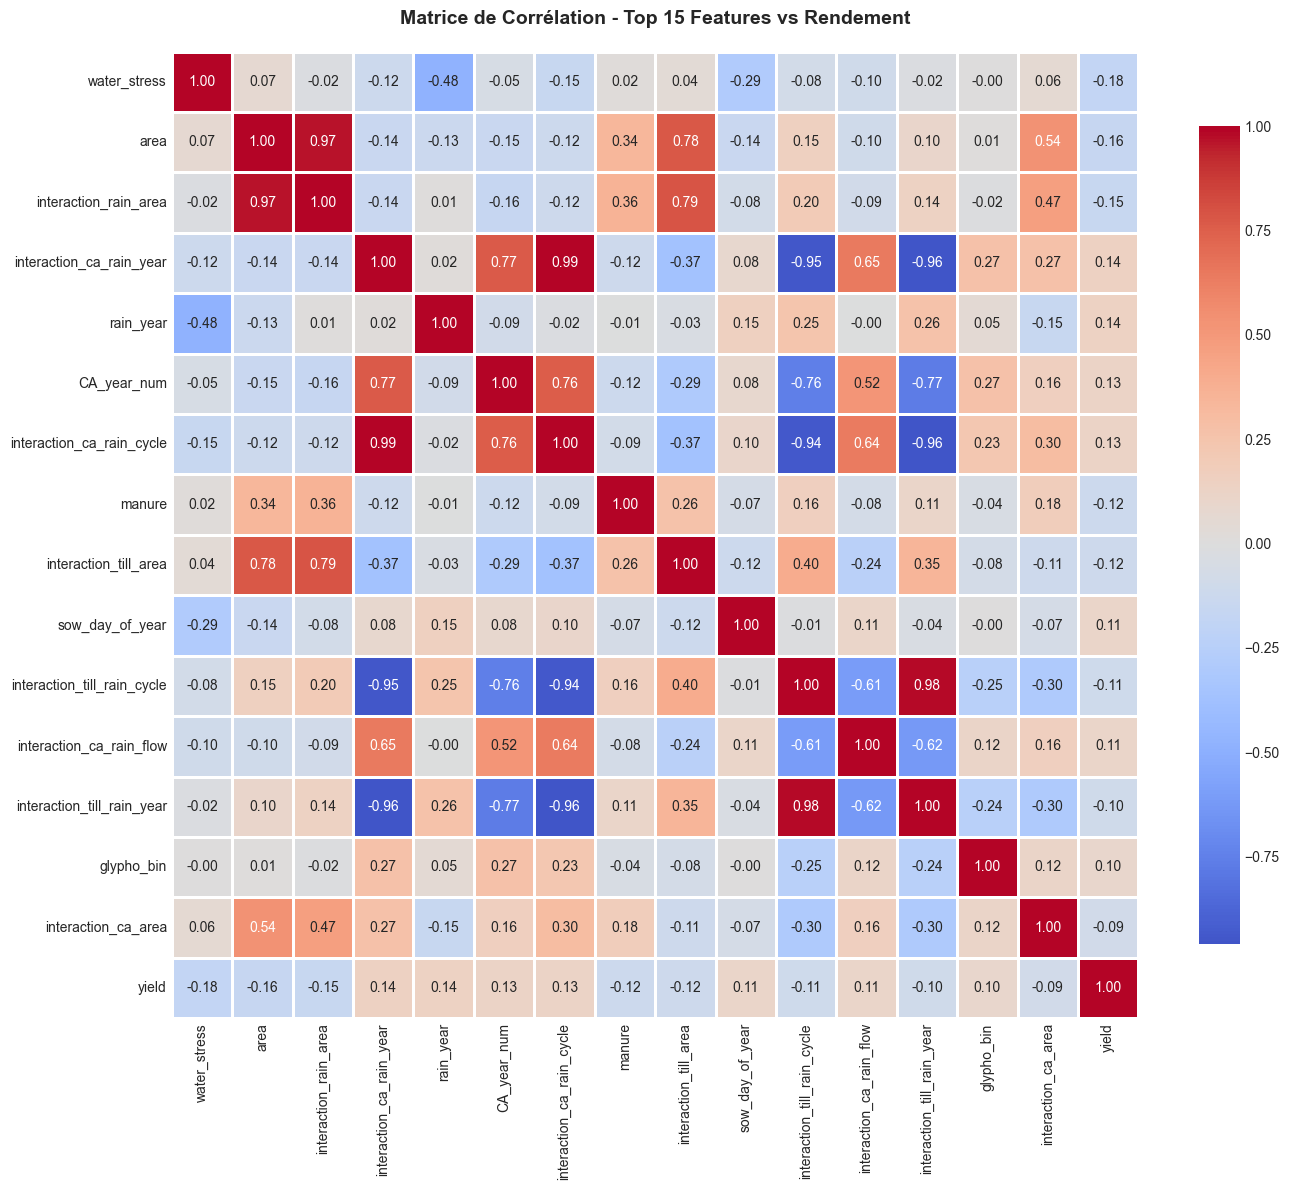


✅ Graphique sauvegardé : ../figures/09_correlation_features.png


In [11]:
# Heatmap des corrélations (top features)
top_features = correlations_yield.abs().sort_values(ascending=False).head(20).index.tolist()
top_features = [f for f in top_features if f != target_col][:15]  # Garder top 15

plt.figure(figsize=(14, 12))
sns.heatmap(df_fe[top_features + [target_col]].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation - Top 15 Features vs Rendement', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/09_correlation_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Graphique sauvegardé : ../figures/09_correlation_features.png")

In [12]:
# Identifier les features fortement corrélées entre elles (multicolinéarité)
print("\n" + "="*80)
print("🔍 DÉTECTION DE LA MULTICOLINÉARITÉ")
print("="*80)

# CORRECTION: Seuil adapté
threshold = 0.85
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            # Ne pas alerter sur les corrélations évidentes (interactions)
            if not (feature1.startswith('interaction_') and feature2 in feature1):
                high_corr_pairs.append({
                    'Feature 1': feature1,
                    'Feature 2': feature2,
                    'Correlation': correlation_matrix.iloc[i, j]
                })

if high_corr_pairs:
    print(f"\n⚠️ {len(high_corr_pairs)} paires de features avec corrélation > {threshold} :")
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.head(10).to_string(index=False))
    print(f"\n💡 Conseil : Ces corrélations peuvent indiquer de la multicolinéarité")
else:
    print(f"\n✅ Aucune multicolinéarité forte détectée (seuil = {threshold})")


🔍 DÉTECTION DE LA MULTICOLINÉARITÉ

⚠️ 15 paires de features avec corrélation > 0.85 :
                  Feature 1                  Feature 2  Correlation
                        npk                  total_npk     1.000000
                 rain_cycle         rain_cycle_squared     0.993832
  interaction_ca_rain_cycle   interaction_ca_rain_year     0.986097
interaction_till_rain_cycle interaction_till_rain_year     0.982367
                   nitrogen  interaction_rain_nitrogen     0.974479
                       area      interaction_rain_area     0.965676
                       urea                   nitrogen     0.964630
 interaction_till_rain_year   interaction_ca_rain_year    -0.960024
  interaction_ca_rain_cycle interaction_till_rain_year    -0.957896
interaction_till_rain_cycle   interaction_ca_rain_year    -0.945211

💡 Conseil : Ces corrélations peuvent indiquer de la multicolinéarité


In [13]:
#7. SÉPARATION TRAIN/TEST (80/20)
print("\n" + "="*80)
print("🔀 SÉPARATION TRAIN/TEST (80/20)")
print("="*80)

# Utiliser 'yield' comme cible
target_col = 'yield'

# Colonnes à exclure
cols_to_drop = [target_col, 'crop_season', 'sow_date', 'sow_date_parsed', 
                'id_field', 'village_grouped', 'sow_date_dt', 'village', 
                'soil', 'tillage_system', 'CA_year', 'x24d', 'glypho']

# Préparer X et y
X = df_fe.drop(columns=[col for col in cols_to_drop if col in df_fe.columns])
y = df_fe[target_col]

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=None
)

print(f"\n📌 Dimensions :")
print(f"   X (features) : {X.shape}")
print(f"   y (cible)    : {y.shape}")

print(f"\n📌 Séparation train/test :")
print(f"   Train set  : {X_train.shape[0]} observations (80%)")
print(f"   Test set   : {X_test.shape[0]} observations (20%)")

print(f"\n📌 Features finales ({X.shape[1]}) :")
print(X.columns.tolist())

# ============================================================================
# SAUVEGARDE DES DATASETS
# ============================================================================

# Sauvegarder les ensembles
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print(f"\n✅ Datasets sauvegardés :")
print(f"   • X_train.csv ({X_train.shape})")
print(f"   • X_test.csv ({X_test.shape})")
print(f"   • y_train.csv ({y_train.shape})")
print(f"   • y_test.csv ({y_test.shape})")


🔀 SÉPARATION TRAIN/TEST (80/20)

📌 Dimensions :
   X (features) : (3803, 43)
   y (cible)    : (3803,)

📌 Séparation train/test :
   Train set  : 3042 observations (80%)
   Test set   : 761 observations (20%)

📌 Features finales (43) :
['area', 'manure', 'urea', 'npk', 'nitrogen', 'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year', 'tillage_ca', 'tillage_till', 'village_Ambohimiarina', 'village_Ambohitsilaozana', 'village_Ambongabe', 'village_Ampitatsimo', 'village_Antsahamamy', 'soil_hillside', 'soil_lowland', 'CA_year_num', 'x24d_bin', 'glypho_bin', 'interaction_till_rain_sow', 'interaction_ca_rain_sow', 'interaction_till_rain_flow', 'interaction_ca_rain_flow', 'interaction_till_rain_cycle', 'interaction_ca_rain_cycle', 'interaction_till_rain_year', 'interaction_ca_rain_year', 'interaction_till_nitrogen', 'interaction_ca_nitrogen', 'interaction_till_area', 'interaction_ca_area', 'ratio_N_urea', 'ratio_N_manure', 'total_npk', 'sow_day_of_year', 'rain_cycle_squared', 'nitrogen_squared

In [14]:
#6. NORMALISATION / STANDARDISATION (déjà inverser d'ordre)
print("\n" + "="*80)
print("🎯 NORMALISATION / STANDARDISATION")
print("="*80)

# Créer une copie pour la normalisation
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Identifier les colonnes à normaliser
cols_to_normalize = []
for col in X_train.columns:
    if X_train[col].nunique() > 2 and not col.startswith(('tillage_', 'village_', 'soil_')) and not col.endswith('_bin'):
        cols_to_normalize.append(col)

print(f"\n📌 Colonnes à normaliser ({len(cols_to_normalize)}) :")
print(cols_to_normalize[:20])
if len(cols_to_normalize) > 20:
    print(f"   ... et {len(cols_to_normalize)-20} autres")

# Standardisation - FIT sur TRAIN seulement!
scaler = StandardScaler()
X_train_scaled[cols_to_normalize] = scaler.fit_transform(X_train[cols_to_normalize])
X_test_scaled[cols_to_normalize] = scaler.transform(X_test[cols_to_normalize])

# Sauvegarder les données scalées
X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv', index=False)
pd.Series(y_train).to_csv('../data/processed/y_train.csv', index=False)
pd.Series(y_test).to_csv('../data/processed/y_test.csv', index=False)

print(f"\n✅ Standardisation effectuée avec StandardScaler")
print(f"   Moyenne après standardisation : {X_train_scaled[cols_to_normalize].mean().mean():.6f}")
print(f"   Écart-type après standardisation : {X_train_scaled[cols_to_normalize].std().mean():.6f}")

# Vérification
print(f"\n📊 Statistiques après standardisation (échantillon TRAIN) :")
print(X_train_scaled[cols_to_normalize[:5]].describe().round(3))

print(f"\n📊 Statistiques après standardisation (échantillon TEST) :")
print(X_test_scaled[cols_to_normalize[:5]].describe().round(3))


🎯 NORMALISATION / STANDARDISATION

📌 Colonnes à normaliser (31) :
['area', 'manure', 'urea', 'npk', 'nitrogen', 'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year', 'CA_year_num', 'interaction_till_rain_sow', 'interaction_ca_rain_sow', 'interaction_till_rain_flow', 'interaction_ca_rain_flow', 'interaction_till_rain_cycle', 'interaction_ca_rain_cycle', 'interaction_till_rain_year', 'interaction_ca_rain_year', 'interaction_till_nitrogen', 'interaction_ca_nitrogen']
   ... et 11 autres

✅ Standardisation effectuée avec StandardScaler
   Moyenne après standardisation : 0.000000
   Écart-type après standardisation : 1.000164

📊 Statistiques après standardisation (échantillon TRAIN) :
           area    manure      urea       npk  nitrogen
count  3042.000  3042.000  3042.000  3042.000  3042.000
mean     -0.000    -0.000     0.000    -0.000     0.000
std       1.000     1.000     1.000     1.000     1.000
min      -0.509    -0.704    -0.560    -0.449    -0.589
25%      -0.503    -0.704    -0.

In [15]:
# Division Train/Test (80/20)
print("\n" + "="*80)
print("🔀 DIVISION TRAIN/TEST")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=None
)

print(f"\n📊 RÉSULTATS DE LA DIVISION :")
print(f"   Ensemble d'entraînement : {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Ensemble de test        : {X_test.shape[0]} observations ({X_test.shape[0]/len(X)*100:.1f}%)")

# Vérifier la distribution de la cible
print(f"\n📊 DISTRIBUTION DU RENDEMENT :")
print(f"   Train - Moyenne : {y_train.mean():.2f}, Écart-type : {y_train.std():.2f}")
print(f"   Test  - Moyenne : {y_test.mean():.2f}, Écart-type : {y_test.std():.2f}")

# Vérifier les ratio min/max
train_min, train_max = y_train.min(), y_train.max()
test_min, test_max = y_test.min(), y_test.max()

print(f"\n📊 PLAGE DE RENDEMENT :")
print(f"   Train - Min : {train_min:.2f}, Max : {train_max:.2f}")
print(f"   Test  - Min : {test_min:.2f}, Max : {test_max:.2f}")

# Afficher les dimensions finales
print(f"\n📌 DIMENSIONS FINALES :")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   y_train : {y_train.shape}")
print(f"   y_test  : {y_test.shape}")


🔀 DIVISION TRAIN/TEST

📊 RÉSULTATS DE LA DIVISION :
   Ensemble d'entraînement : 3042 observations (80.0%)
   Ensemble de test        : 761 observations (20.0%)

📊 DISTRIBUTION DU RENDEMENT :
   Train - Moyenne : 2559.50, Écart-type : 908.41
   Test  - Moyenne : 2594.62, Écart-type : 908.02

📊 PLAGE DE RENDEMENT :
   Train - Min : 318.00, Max : 5350.00
   Test  - Min : 431.60, Max : 5300.00

📌 DIMENSIONS FINALES :
   X_train : (3042, 43)
   X_test  : (761, 43)
   y_train : (3042,)
   y_test  : (761,)


In [16]:
# 8. SAUVEGARDE DES DONNÉES PRÉPARÉES
print("\n" + "="*80)
print("💾 SAUVEGARDE DES DONNÉES PRÉPARÉES")
print("="*80)

import os

os.makedirs('./data/processed', exist_ok=True)
os.makedirs('./models', exist_ok=True)

X_train.to_csv('./data/processed/X_train.csv', index=False)
X_test.to_csv('./data/processed/X_test.csv', index=False)
y_train.to_csv('./data/processed/y_train.csv', index=False)
y_test.to_csv('./data/processed/y_test.csv', index=False)

print(f"\n✅ Données Train/Test sauvegardées :")
print(f"   • X_train.csv ({X_train.shape})")
print(f"   • X_test.csv ({X_test.shape})")
print(f"   • y_train.csv ({y_train.shape})")
print(f"   • y_test.csv ({y_test.shape})")

df_fe.to_csv('./data/processed/data_with_features.csv', index=False)
print(f"\n✅ Données avec feature engineering :")
print(f"   • data_with_features.csv ({df_fe.shape})")

features_list = X.columns.tolist()
with open('./data/processed/features_list.txt', 'w', encoding='utf-8') as f:
    for feature in features_list:
        f.write(f"{feature}\n")

print(f"\n✅ Liste des features sauvegardée :")
print(f"   • features_list.txt ({len(features_list)} features)")

print(f"\n📊 RÉSUMÉ DES FICHIERS SAUVEGARDÉS :")
print(f"   Dossier: ./data/processed/")
print(f"   - X_train.csv, X_test.csv")
print(f"   - y_train.csv, y_test.csv")
print(f"   - data_with_features.csv")
print(f"   - features_list.txt")


💾 SAUVEGARDE DES DONNÉES PRÉPARÉES

✅ Données Train/Test sauvegardées :
   • X_train.csv ((3042, 43))
   • X_test.csv ((761, 43))
   • y_train.csv ((3042,))
   • y_test.csv ((761,))

✅ Données avec feature engineering :
   • data_with_features.csv ((3803, 53))

✅ Liste des features sauvegardée :
   • features_list.txt (43 features)

📊 RÉSUMÉ DES FICHIERS SAUVEGARDÉS :
   Dossier: ./data/processed/
   - X_train.csv, X_test.csv
   - y_train.csv, y_test.csv
   - data_with_features.csv
   - features_list.txt



📊 VISUALISATION FINALE


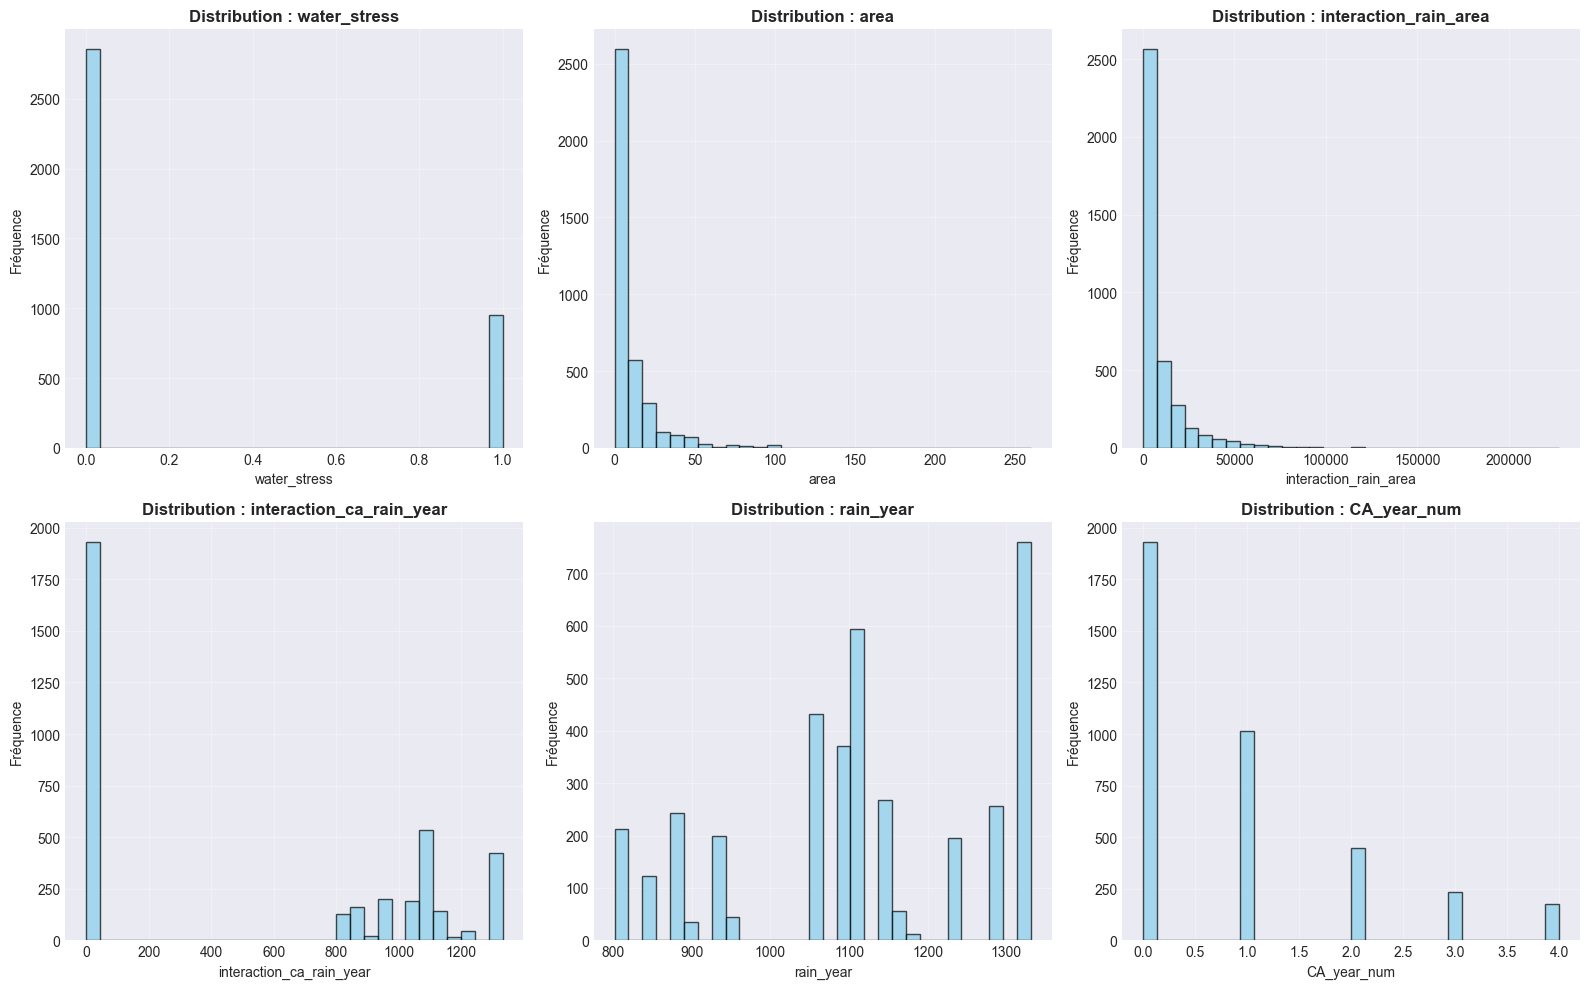


✅ Graphique sauvegardé : ../figures/10_features_distribution.png


In [17]:
#9. VISUALISATION FINALE DES FEATURES
print("\n" + "="*80)
print("📊 VISUALISATION FINALE")
print("="*80)

# Distribution de quelques features clés
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Sélectionner les top features corrélées avec le rendement
if 'correlations_yield' in dir():
    top_features_viz = correlations_yield.abs().sort_values(ascending=False).head(7)[1:].index.tolist()
else:
    top_features_viz = ['yield', 'nitrogen', 'rain_cycle', 'area', 'efficiency_N', 'interaction_rain_nitrogen']
    top_features_viz = [f for f in top_features_viz if f in df_fe.columns]

for idx, feature in enumerate(top_features_viz[:6]):
    if feature in df_fe.columns:
        axes[idx].hist(df_fe[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution : {feature}', fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Fréquence')
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/10_features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : ../figures/10_features_distribution.png")

In [18]:
#10. RÉSUMÉ FINAL
print("\n" + "="*80)
print("📝 RÉSUMÉ - FEATURE ENGINEERING")
print("="*80)

# CORRECTION: Compter les nouvelles features
original_cols = df.columns.tolist()
new_cols = [col for col in df_fe.columns if col not in original_cols]
n_new_features = len(new_cols)

# Top corrélations
if 'correlations_yield' in dir():
    top1 = correlations_yield.index[1] if len(correlations_yield) > 1 else "N/A"
    corr1 = correlations_yield.iloc[1] if len(correlations_yield) > 1 else 0
    top2 = correlations_yield.index[2] if len(correlations_yield) > 2 else "N/A"
    corr2 = correlations_yield.iloc[2] if len(correlations_yield) > 2 else 0
    top3 = correlations_yield.index[3] if len(correlations_yield) > 3 else "N/A"
    corr3 = correlations_yield.iloc[3] if len(correlations_yield) > 3 else 0
else:
    top1, corr1, top2, corr2, top3, corr3 = "N/A", 0, "N/A", 0, "N/A", 0

summary = f"""
FEATURE ENGINEERING - RÉSUMÉ
{'='*80}

1. DONNÉES INITIALES
   - Observations : {len(df)}
   - Variables originales : {df.shape[1]}

2. ENCODAGE DES VARIABLES CATÉGORIELLES
   - Variables encodées : {categorical_cols}
   - One-Hot Encoding sur : tillage_system, village, soil
   - Encoding ordinal sur : CA_year

3. NOUVELLES FEATURES CRÉÉES
   ✅ Interactions système × pluviométrie et fertilisation
   ✅ Ratios de fertilisation (N/urea, N/manure)
   ✅ Indicateurs temporels (sow_day_of_year)
   ✅ Jour de semis (sow_day_of_year)
   ✅ Variables quadratiques (rain_cycle², nitrogen², area²)
   ✅ Indice de stress hydrique (water_stress)
   ✅ Efficacité d'utilisation de l'azote (efficiency_N)

4. NOMBRE TOTAL DE FEATURES
   - Features après engineering : {X.shape[1]}
   - Nouvelles features créées : {n_new_features}
   - Augmentation : {n_new_features} nouvelles features

5. NORMALISATION
   - Méthode : StandardScaler (mean=0, std=1)
   - Features normalisées : {len(cols_to_normalize)}

6. DIVISION TRAIN/TEST
   - Train : {X_train.shape[0]} observations (80%)
   - Test : {X_test.shape[0]} observations (20%)

7. CORRÉLATIONS AVEC LE RENDEMENT
   - Top feature : {top1} (r = {corr1:.4f})
   - 2ème feature : {top2} (r = {corr2:.4f})
   - 3ème feature : {top3} (r = {corr3:.4f})

8. FICHIERS SAUVEGARDÉS
   ✅ X_train.csv, X_test.csv, y_train.csv, y_test.csv
   ✅ data_with_features.csv (non normalisées)
   ✅ data_normalized.csv
   ✅ features_list.txt
   ✅ scaler.pkl
   ✅ Graphiques de corrélation (09) et distribution (10)

{'='*80}
"""

print(summary)

# Sauvegarder le résumé
os.makedirs('../results', exist_ok=True)
with open('../results/03_resume_feature_engineering.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✅ Résumé sauvegardé : ../results/03_resume_feature_engineering.txt")
print("\n🎉 FEATURE ENGINEERING TERMINÉ !")
print("\n🚀 PROCHAINE ÉTAPE : Notebook 4 - Modèles de Base (Baseline)")


📝 RÉSUMÉ - FEATURE ENGINEERING

FEATURE ENGINEERING - RÉSUMÉ

1. DONNÉES INITIALES
   - Observations : 3803
   - Variables originales : 20

2. ENCODAGE DES VARIABLES CATÉGORIELLES
   - Variables encodées : ['village', 'soil', 'tillage_system', 'CA_year', 'x24d', 'glypho']
   - One-Hot Encoding sur : tillage_system, village, soil
   - Encoding ordinal sur : CA_year

3. NOUVELLES FEATURES CRÉÉES
   ✅ Interactions système × pluviométrie et fertilisation
   ✅ Ratios de fertilisation (N/urea, N/manure)
   ✅ Indicateurs temporels (sow_day_of_year)
   ✅ Jour de semis (sow_day_of_year)
   ✅ Variables quadratiques (rain_cycle², nitrogen², area²)
   ✅ Indice de stress hydrique (water_stress)
   ✅ Efficacité d'utilisation de l'azote (efficiency_N)

4. NOMBRE TOTAL DE FEATURES
   - Features après engineering : 43
   - Nouvelles features créées : 35
   - Augmentation : 35 nouvelles features

5. NORMALISATION
   - Méthode : StandardScaler (mean=0, std=1)
   - Features normalisées : 31

6. DIVISION 